## Capstone Project - Bundestag Data Set

Parliamentary debates protocols from 1949-2021

**Political Argument Assistant**

Business Goal: "what arguments where put forward in favor and against the EURO"?
   
Evaluation Metric: Accuracy?




### Questions

- data cleaning: 
    - remove (CDU)/ (SPD) etc from speech_identification_ent cols
    - Role vs pos_speechbeginning
    - beginning and end of speech: interruptions?
    - check for other values surrounding \* # remove or ignore \n, \t and words such as 'Euro-\npa' in column 'text'?
    - Löbe/ Labe: parsing errors


### 1. Init

In [2]:
# data handling & viz
import pandas as pd
import matplotlib.pyplot as plt

# language-related packages
import re #regex
from wordcloud import WordCloud
import spacy # DE stopwords

# other
import warnings
warnings.filterwarnings('ignore')


In [3]:
df_raw_debates = pd.read_csv("data/all_bundestag_speeches_replication_data.csv")

In [4]:
df_raw_debates.shape

(877140, 13)

In [5]:
df_raw_debates.columns.to_list()

['Unnamed: 0',
 'doc_id',
 'doc_lp_id',
 'speech_identification_ent',
 'date',
 'period',
 'session',
 'pos_speechbeginning',
 'Party',
 'Role',
 'governing_Party',
 'text',
 'text_length']

In [6]:
df_raw_debates.head()

,Unnamed: 0,doc_id,doc_lp_id,speech_identification_ent,date,period,session,pos_speechbeginning,Party,Role,governing_Party,text,text_length
0,0,0,0,Alterspräsident Labe:,07.09.1949,1,1,\nAlterspräsident Labe:,no-text,Alterspraesident,no-text,Meine Damen und Herren! Abgeordnete des Deuts...,1670
1,1,1,1,Dr. Adenauer (CDU):,07.09.1949,1,1,\nDr. Adenauer (CDU):,CDU/CSU,MdB,1.0,Namens der Fraktion der CDU/CSU schlage ich a...,15
2,2,2,2,Alterspräsident Löbe:,07.09.1949,1,1,\nAlterspräsident Löbe:,no-text,Alterspraesident,no-text,Das Wort hat der Herr Abgeordnete Reimann.\n,7
3,3,3,3,Reimann (KPD):,07.09.1949,1,1,\nReimann (KPD):,KPD,MdB,0.0,Ich schlage im Namen der kommunistischen Frak...,22
4,4,4,4,Alterspräsident Löbe:,07.09.1949,1,1,\nAlterspräsident Löbe:,no-text,Alterspraesident,no-text,Sie haben die Vorschläge gehört: Hans Böhm un...,57


In [7]:
df_raw_debates.describe()

,Unnamed: 0,doc_id,doc_lp_id,period,session,text_length
count,877140.000000,877140.000000,877140.000000,877140.000000,877140.000000,877140.000000
mean,438569.500000,438569.500000,25356.538075,10.675568,120.529621,245.665244
std,253208.651896,253208.651896,16277.215712,4.956654,68.088480,629.664638
min,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000
25%,219284.750000,219284.750000,11541.000000,7.000000,63.000000,10.000000
50%,438569.500000,438569.500000,23320.000000,11.000000,119.000000,43.000000
75%,657854.250000,657854.250000,38221.000000,15.000000,175.000000,193.000000
max,877139.000000,877139.000000,63829.000000,19.000000,282.000000,47655.000000


In [8]:
df_raw_debates.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 877140 entries, 0 to 877139
Data columns (total 13 columns):
 #   Column                     Non-Null Count   Dtype 
---  ------                     --------------   ----- 
 0   Unnamed: 0                 877140 non-null  int64 
 1   doc_id                     877140 non-null  int64 
 2   doc_lp_id                  877140 non-null  int64 
 3   speech_identification_ent  877140 non-null  object
 4   date                       877140 non-null  object
 5   period                     877140 non-null  int64 
 6   session                    877140 non-null  int64 
 7   pos_speechbeginning        877140 non-null  object
 8   Party                      877140 non-null  object
 9   Role                       877140 non-null  object
 10  governing_Party            875074 non-null  object
 11  text                       875086 non-null  object
 12  text_length                877140 non-null  int64 
dtypes: int64(6), object(7)
memory usage: 87.0+ M

### 2. Data Cleaning

In [9]:
# set datetime
df_raw_debates['date'] = pd.to_datetime(df_raw_debates['date'], format='%d.%m.%Y')


In [10]:
# drop column 'Unnamed: 0'
df_raw_debates = df_raw_debates.drop(columns=['Unnamed: 0'])

In [11]:
# drop column 'pos_speechbeginning'
df_raw_debates = df_raw_debates.drop(columns=['pos_speechbeginning'])

In [12]:
# allocate governing_Party = 0 where Party == 'fraktionslos' (i.e. independent MP)
df_raw_debates.loc[df_raw_debates['Party'] == 'fraktionslos', 'governing_Party'] = 0

# allocate governing_Party = 0 where Party == 'parteilos' 
df_raw_debates.loc[df_raw_debates['Party'] == 'parteilos', 'governing_Party'] = 0

# allocate governing_Party = 0 where Party == 'DRP' 
df_raw_debates.loc[df_raw_debates['Party'] == 'DRP', 'governing_Party'] = 0

# allocate governing_Party = 0 where Party == 'DPB' 
df_raw_debates.loc[df_raw_debates['Party'] == 'DPB', 'governing_Party'] = 0

In [13]:
# allocate governing_Party = 0 where '0.0' or '0'
df_raw_debates.loc[df_raw_debates['governing_Party'].isin(['0.0', '0']), 'governing_Party'] = 0

# allocate governing_Party = 1 where '1.0' or '1'
df_raw_debates.loc[df_raw_debates['governing_Party'].isin(['1.0', '1']), 'governing_Party'] = 1

In [14]:
# check values for governing_Party
df_raw_debates['governing_Party'].unique()

array(['no-text', 1, 0], dtype=object)

In [15]:
# check where no gov party indicated
df_na_party = df_raw_debates[df_raw_debates['governing_Party'].isna()].copy()
df_na_party.shape


(0, 11)

In [16]:
# show where no text indicated (empty cell)
df_na_text = df_raw_debates[df_raw_debates['text'].isna()].copy()
df_na_text.shape

(2054, 11)

In [17]:
# drop where no text indicated (empty cell)
df_raw_debates = df_raw_debates.dropna(subset=['text']).copy()

In [18]:
# show where text_length is 0
df_zero_text = df_raw_debates[df_raw_debates['text_length'] == 0].copy()
df_zero_text.shape

(260, 11)

In [19]:
# drop rows where text_length is 0 
df_raw_debates = df_raw_debates[df_raw_debates['text_length'] != 0].copy()


In [20]:
# below 1-5: example cleaning for \n
# 1️⃣ Filter for the specific row by id
example_row = df_raw_debates[df_raw_debates['doc_id'] == 744292].copy()
example_row

,doc_id,doc_lp_id,speech_identification_ent,date,period,session,Party,Role,governing_Party,text,text_length
744292,744292,10050,Präsident Dr. Norbert Lammert:,2010-06-10,17,46,no-text,Bundestagspraesident,no-text,\nDas Wort erhält nun der Kollege Manfred Zöll...,11


In [21]:
# 2️⃣ Show original text
print("Original text:")
print(repr(example_row['text'].values[0]))

Original text:
'\nDas Wort erhält nun der Kollege Manfred Zöllmer für\n\ndie SPD-Fraktion.\n\n\n'


In [22]:
# 3️⃣ Replace all newline characters (\n) with a space
example_row['text_cleaned'] = example_row['text'].str.replace(r'\n+', ' ', regex=True)


In [23]:
# 4️⃣ Strip leading/trailing spaces and collapse multiple spaces
example_row['text_cleaned'] = example_row['text_cleaned'].str.strip().str.replace(r'\s+', ' ', regex=True)


In [24]:
# 5️⃣ Show cleaned text
print("\nCleaned text:")
print(repr(example_row['text_cleaned'].values[0]))


Cleaned text:
'Das Wort erhält nun der Kollege Manfred Zöllmer für die SPD-Fraktion.'


In [25]:
# check for cells containing \t (tab)
df_tab_debates = df_raw_debates[df_raw_debates['text'].str.contains('r\t', na=False)].copy()
df_tab_debates.shape

(477, 11)

In [34]:
# check for cells containing \n (tab)
df_tab_debates = df_raw_debates[df_raw_debates['text'].str.contains('r\n', na=False)].copy()
df_tab_debates.shape

(115, 11)

In [38]:
# remove \n from text columns
BATCH_SIZE_RM = 5000

for start in range(0, len(df_raw_debates), BATCH_SIZE_RM):
    end = min(start + BATCH_SIZE_RM, len(df_raw_debates))
    df_raw_debates.loc[start:end-1, 'text'] = (
        df_raw_debates.loc[start:end-1, 'text']
        .str.replace(r'\n+', ' ', regex=True)
        .str.replace(r'\xa0', ' ', regex=False)
        .str.replace(r'\s+', ' ', regex=True)
        .str.strip()
    )
    print(f"Processed rows {start} to {end}")

print("Done.")

Processed rows 0 to 5000
Processed rows 5000 to 10000
Processed rows 10000 to 15000
Processed rows 15000 to 20000
Processed rows 20000 to 25000
Processed rows 25000 to 30000
Processed rows 30000 to 35000
Processed rows 35000 to 40000
Processed rows 40000 to 45000
Processed rows 45000 to 50000
Processed rows 50000 to 55000
Processed rows 55000 to 60000
Processed rows 60000 to 65000
Processed rows 65000 to 70000
Processed rows 70000 to 75000
Processed rows 75000 to 80000
Processed rows 80000 to 85000
Processed rows 85000 to 90000
Processed rows 90000 to 95000
Processed rows 95000 to 100000
Processed rows 100000 to 105000
Processed rows 105000 to 110000
Processed rows 110000 to 115000
Processed rows 115000 to 120000
Processed rows 120000 to 125000
Processed rows 125000 to 130000
Processed rows 130000 to 135000
Processed rows 135000 to 140000
Processed rows 140000 to 145000
Processed rows 145000 to 150000
Processed rows 150000 to 155000
Processed rows 155000 to 160000
Processed rows 160000

In [45]:
# check again for cells containing new line \n 
df_nl_debates = df_raw_debates[df_raw_debates['text'].str.contains('r\n', na=False)].copy()
df_nl_debates.shape

(0, 11)

In [46]:
# rerun cleaning on remaining rows only
mask = df_raw_debates['text'].str.contains(r'\n|\xa0', regex=True, na=False)
remaining_idx = df_raw_debates[mask].index

for start in range(0, len(remaining_idx), BATCH_SIZE_RM):
    batch_idx = remaining_idx[start:start + BATCH_SIZE_RM]
    df_raw_debates.loc[batch_idx, 'text'] = (
        df_raw_debates.loc[batch_idx, 'text']
        .str.replace(r'\n+', ' ', regex=True)
        .str.replace(r'\xa0', ' ', regex=False)
        .str.replace(r'\s+', ' ', regex=True)
        .str.strip()
    )

# verify
mask = df_raw_debates['text'].str.contains(r'\n|\xa0', regex=True, na=False)
print(f"Remaining rows: {mask.sum()}")

Remaining rows: 0


In [82]:
# drop rows where speech_ident column is " " 
df_raw_debates = df_raw_debates[df_raw_debates['speech_identification_ent'].str.strip().str.len() > 1]

In [82]:
# drop texts of length 2 or shorter - low semantic value
df_raw_debates = df_raw_debates[df_raw_debates['text_length'] > 2]

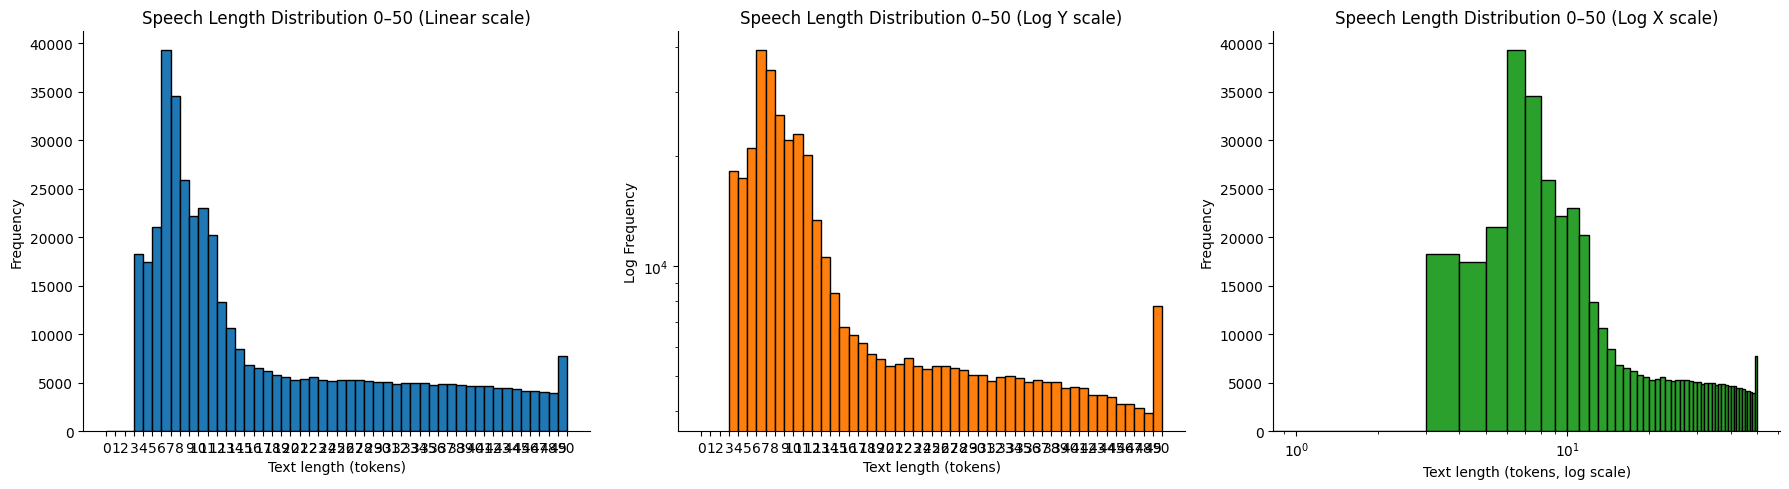

In [68]:
# Filter for text_length between 0 and 50
df_filtered = df_raw_debates[df_raw_debates['text_length'].between(0, 50)]

# Three subplots side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

bins = range(0, 51)  # bins from 0 to 51 to capture 0–50

# Linear scale histogram
axes[0].hist(df_filtered['text_length'], bins=bins, color='C0', edgecolor='black')
axes[0].set_xlabel('Text length (tokens)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Speech Length Distribution 0–50 (Linear scale)')
axes[0].set_xticks(range(0, 51))
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Logarithmic scale on y-axis
axes[1].hist(df_filtered['text_length'], bins=bins, color='C1', edgecolor='black', log=True)
axes[1].set_xlabel('Text length (tokens)')
axes[1].set_ylabel('Log Frequency')
axes[1].set_title('Speech Length Distribution 0–50 (Log Y scale)')
axes[1].set_xticks(range(0, 51))
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# Logarithmic scale on x-axis
axes[2].hist(df_filtered['text_length'], bins=bins, color='C2', edgecolor='black')
axes[2].set_xscale('log')
axes[2].set_xlabel('Text length (tokens, log scale)')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Speech Length Distribution 0–50 (Log X scale)')
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('images/speech_length_distribution_0_50.png')
plt.show()

In [27]:
# rows where a word is split across a newline with a hyphen
hyphen_linebreaks = df_raw_debates[df_raw_debates['text'].str.contains(r'\w-\n\w', regex=True, na=False)].copy()

# num of rows
print(f"Rows with hyphen-line breaks: {len(hyphen_linebreaks)}")

Rows with hyphen-line breaks: 186059


In [28]:
# check for stray '\' in text column
slash_text_col = df_raw_debates[df_raw_debates['text'].str.contains(r'\\', na=False)]
slash_text_col

,doc_id,doc_lp_id,speech_identification_ent,date,period,session,Party,Role,governing_Party,text,text_length
105,105,105,Ewers (DP):,1949-09-22,1,7,DP,MdB,1,Meine sehr geehrten Damen und Herren! Die Stu...,2144
2989,2989,2989,Dr. Horlacher (CSU):,1950-03-22,1,49,CDU/CSU,MdB,1,Meine Damen und Herren! Ich möchte idem Antra...,1054
3599,3599,3599,Tichi (WAV):,1950-04-26,1,58,WAV,MdB,0,Herr Präsident! Meine Damen und Herren! Auch ...,545
4895,4895,4895,"Kurlbaum (SPD), Interpellant:",1950-07-14,1,75,SPD,MdB,0,Herr Präsident! Meine Damen und Herren! Bevor...,1419
4987,4987,4987,"Kurlbaum (SPD), Interpellant:",1950-07-14,1,76,SPD,MdB,0,Herr Präsident! Meine Damen und Herren! Bevor...,1400
...,...,...,...,...,...,...,...,...,...,...,...
678839,678839,33604,Vizepräsidentin Dr. Antje Vollmer:,2005-03-18,15,167,no-text,Vizepraesident,no-text,\nDie Parlamentarische Staatssekretärin Angeli...,99
678841,678841,33606,Vizepräsidentin Dr. Antje Vollmer:,2005-03-18,15,167,no-text,Vizepraesident,no-text,"\nDanke schön, auch für die Kürze der Rede. Ic...",306
678842,678842,33607,Peter Rzepka (CDU/CSU):,2005-03-18,15,167,CDU/CSU,MdB,0,\nFrau Präsidentin! Meine sehr geehrten Damen ...,1561
678844,678844,33609,Hellmut Königshaus (FDP):,2005-03-18,15,167,FDP,MdB,0,\nFrau Präsidentin! Meine Damen und Herren! Ic...,526


In [69]:
df_raw_debates.shape

(840699, 11)

In [31]:
# all unique roles
raw_roles = df_raw_debates['Role'].unique()
raw_roles

array(['Alterspraesident', 'MdB', 'Bundestagspraesident',
       'Schriftfuehrer', 'Bundeskanzler', 'Bundesminister',
       'Vizepraesident', 'Staatssekretär', 'Staatsminister',
       'Landesminister', 'Senator', 'Buergermeister', 'Gastredner',
       'Wehrbeauftragter', 'Beauftragter'], dtype=object)

In [32]:
# all unique parties
party = df_raw_debates['Party'].unique()
party

array(['no-text', 'CDU/CSU', 'KPD', 'SPD', 'FDP', 'BP', 'Cabinet', 'DP',
       'Zentrum', 'NR', 'WAV', 'parteilos', 'NS', 'DRP', 'SRP', 'GB/BHE',
       'fraktionslos', 'FU', 'DPB', 'DA', 'GRÜNE', 'PDS', 'LINKE', 'AfD'],
      dtype=object)

In [33]:
df_gastredner = df_raw_debates[df_raw_debates['Role'] == 'Gastredner']
df_gastredner

,doc_id,doc_lp_id,speech_identification_ent,date,period,session,Party,Role,governing_Party,text,text_length
24588,24588,93,"Mr. Joseph W. Martin, Speaker des. Repräsentan...",1953-10-29,2,5,no-text,Gastredner,no-text,"\nEs ist eine große Ehre für mich, vor dieser ...",1228


In [49]:
# irrelevant roles to be dropped, effectively keep same as LNKTW24
irr_roles = ['Gastredner', 'Landesminister', 'Bundestagspraesident', 'Vizepraesident', 'Alterspraesident', 'Senator', 'Buergermeister', 'Wehrbeauftragter', 'Beauftragter', 'Schriftfuehrer']

# LNKTW2024 keep only ['MdB','Bundeskanzler','Bundesminister','Staatssekretär', 'Staatsminister']
roles = ['MdB','Bundeskanzler','Bundesminister','Staatssekretär', 'Staatsminister']

# all roles
all_roles = roles + irr_roles

In [50]:
# irrelevant speeches (procedural, guest speakers, non-members of Parliament)
irr_debates = df_raw_debates[df_raw_debates['Role'].isin(irr_roles)].copy()
irr_debates.shape

(353697, 11)

### 2.1 Cleaned Data & Key Parameters 


In [51]:
# cleaned dataframe for further processing
df_debates = df_raw_debates[df_raw_debates['Role'].isin(roles)].copy()
df_debates.shape

(521129, 11)

In [53]:
irr_debates.nunique()

doc_id                       353697
doc_lp_id                     61994
speech_identification_ent      1358
date                           4092
period                           19
session                         282
Party                             1
Role                             10
governing_Party                   2
text                         249032
text_length                    3349
dtype: int64

In [54]:
df_debates.nunique()

doc_id                       521129
doc_lp_id                     63078
speech_identification_ent     15448
date                           4280
period                           19
session                         282
Party                            23
Role                              5
governing_Party                   2
text                         501932
text_length                    5427
dtype: int64

In [55]:
df_debates.info()

<class 'pandas.core.frame.DataFrame'>
Index: 521129 entries, 1 to 877139
Data columns (total 11 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   doc_id                     521129 non-null  int64         
 1   doc_lp_id                  521129 non-null  int64         
 2   speech_identification_ent  521129 non-null  object        
 3   date                       521129 non-null  datetime64[ns]
 4   period                     521129 non-null  int64         
 5   session                    521129 non-null  int64         
 6   Party                      521129 non-null  object        
 7   Role                       521129 non-null  object        
 8   governing_Party            521129 non-null  object        
 9   text                       521129 non-null  object        
 10  text_length                521129 non-null  int64         
dtypes: datetime64[ns](1), int64(5), object(5)
memory usage: 4

In [56]:
# columns pos_speechbeginning is dropped
# check where values of pos_speechbeginning == no-text
#df_na_speech_beg = df_debates[df_debates['pos_speechbeginning']=='no-text']
#df_na_speech_beg

In [57]:
# columns pos_speechbeginning is dropped
# show df where pos_speechbeginning contains a party tag like (SPD), (CDU), ...
#df_party_tags = df_debates[df_debates['pos_speechbeginning'].str.contains(r'\([A-ZÄÖÜ/]+\)', na=False)]


In [58]:
# unique parties
df_debates['Party'].unique()

# fraktionslos =/= parteilos

array(['CDU/CSU', 'KPD', 'SPD', 'FDP', 'BP', 'Cabinet', 'DP', 'Zentrum',
       'NR', 'WAV', 'parteilos', 'NS', 'DRP', 'SRP', 'GB/BHE',
       'fraktionslos', 'FU', 'DPB', 'DA', 'GRÜNE', 'PDS', 'LINKE', 'AfD'],
      dtype=object)

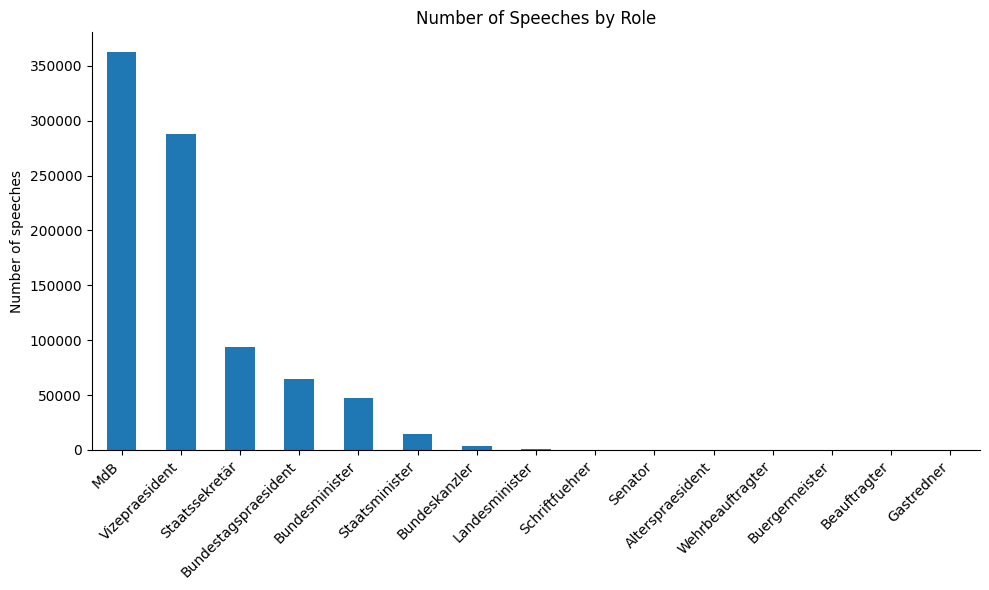

In [59]:
# Count total number of speeches per role
role_counts = df_raw_debates['Role'].value_counts().reindex(all_roles).sort_values(ascending=False) 

# Plot
plt.figure(figsize=(10,6))
ax = role_counts.plot(kind='bar', color='C0') 

# save ink
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.ylabel('Number of speeches')
plt.xlabel('')
plt.title('Number of Speeches by Role')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('images/raw_all_speeches_by_role.png')
plt.show()

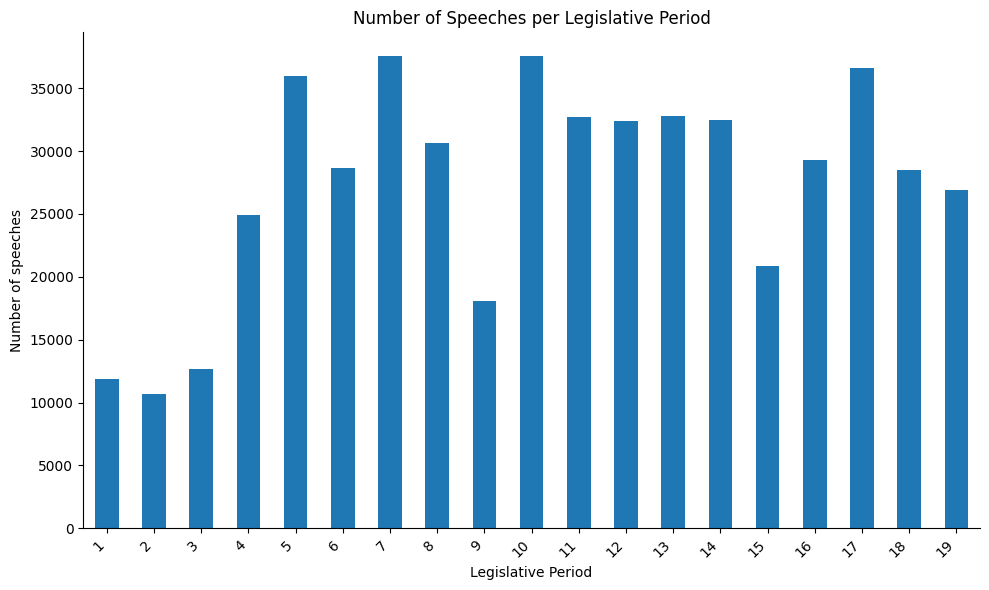

In [60]:
# Count speeches per period
speeches_per_period = df_debates.groupby('period')['doc_id'].count().sort_index()

# Plot
plt.figure(figsize=(10,6))
ax = speeches_per_period.plot(kind='bar', color='C0')

# Remove top/right spines for cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.ylabel('Number of speeches')
plt.xlabel('Legislative Period')
plt.title('Number of Speeches per Legislative Period')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

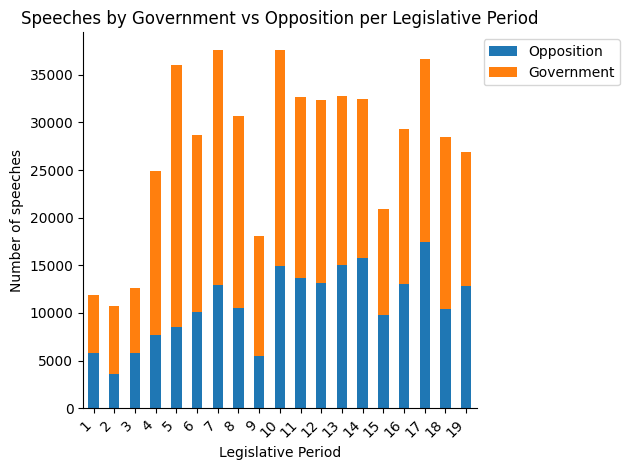

In [61]:
# plot government vs opposition contributions
stacked_counts = (
    df_debates
    .groupby(['period', 'governing_Party'])['doc_id']
    .count()
    .unstack(fill_value=0)
    .sort_index()
)
stacked_counts = stacked_counts.rename(
    columns={0: 'Opposition', 1: 'Government'}
)

plt.figure(figsize=(10,6))
ax = stacked_counts.plot(kind='bar', stacked=True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.ylabel('Number of speeches')
plt.xlabel('Legislative Period')
plt.title('Speeches by Government vs Opposition per Legislative Period')
plt.xticks(rotation=45, ha='right')

# move legend outside to the upper right
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.savefig('images/speeches_over_lps.png', bbox_inches='tight')  # bbox_inches='tight' ensures legend isn't clipped
plt.show()

In [62]:
# parties per period
df_debates.groupby('period')['Party'].nunique()

period
1     18
2      8
3      6
4      4
5      4
6      5
7      5
8      5
9      5
10     6
11     7
12     7
13     7
14     7
15     6
16     7
17     7
18     6
19     8
Name: Party, dtype: int64

In [63]:
# all parties in government per period
df_debates[df_debates['governing_Party']==1].groupby('period')['Party'].unique()

period
1             [CDU/CSU, FDP, Cabinet, DP]
2     [CDU/CSU, FDP, Cabinet, GB/BHE, DP]
3                  [CDU/CSU, Cabinet, DP]
4                 [CDU/CSU, FDP, Cabinet]
5            [CDU/CSU, Cabinet, FDP, SPD]
6                     [SPD, Cabinet, FDP]
7                     [SPD, FDP, Cabinet]
8                     [SPD, FDP, Cabinet]
9            [SPD, FDP, Cabinet, CDU/CSU]
10                [CDU/CSU, FDP, Cabinet]
11                [CDU/CSU, FDP, Cabinet]
12                [CDU/CSU, FDP, Cabinet]
13                [CDU/CSU, FDP, Cabinet]
14                  [SPD, GRÜNE, Cabinet]
15                  [SPD, GRÜNE, Cabinet]
16                [CDU/CSU, SPD, Cabinet]
17                [CDU/CSU, FDP, Cabinet]
18                [CDU/CSU, SPD, Cabinet]
19                [SPD, CDU/CSU, Cabinet]
Name: Party, dtype: object

In [64]:
# cabinet = government members
df_cabinet = df_debates[df_debates['Party']=='Cabinet'].copy()
df_cabinet.shape

(158839, 11)

In [65]:
# this should be 1. All Party=Cabinet are also gov_Party=1. 
df_cabinet['governing_Party'].nunique()

1

In [66]:
df_debates

,doc_id,doc_lp_id,speech_identification_ent,date,period,session,Party,Role,governing_Party,text,text_length
1,1,1,Dr. Adenauer (CDU):,1949-09-07,1,1,CDU/CSU,MdB,1,Namens der Fraktion der CDU/CSU schlage ich al...,15
3,3,3,Reimann (KPD):,1949-09-07,1,1,KPD,MdB,0,Ich schlage im Namen der kommunistischen Frakt...,22
5,5,5,Böhm (SPD):,1949-09-07,1,1,SPD,MdB,0,"Zu dem Vorschlag der kommunistischen Fraktion,...",21
8,8,8,Ollenhauer (SPD):,1949-09-07,1,1,SPD,MdB,0,Im Namen der sozialdemokratischen Fraktion sch...,16
10,10,10,Dr. Heuss (FDP):,1949-09-07,1,1,FDP,MdB,1,Im Auftrag der Freien Demokraten schlage ich a...,15
...,...,...,...,...,...,...,...,...,...,...,...
877135,877135,26943,Frank Schäffler,2021-09-07,19,239,FDP,MdB,0,Die Flutkatastrophe hat eine bis dahin beispie...,181
877136,877136,26944,Hermann Otto Solms,2021-09-07,19,239,FDP,MdB,0,Dass die Bundesregierung mehrere weitreichende...,42
877137,877137,26945,Linda Teuteberg,2021-09-07,19,239,FDP,MdB,0,Die Flutkatastrophe hat eine bis dahin beispie...,177
877138,877138,26946,Dietlind Tiemann,2021-09-07,19,239,CDU/CSU,MdB,1,Obwohl ich die Abkehr von der Sieben-Tage-Indi...,206


In [67]:
# text length by distribution percentile
pd.DataFrame(df_debates.text_length).describe(percentiles=[0.05, 0.1, 0.15, 0.25, 0.5, 0.75, 0.8, 0.9, 0.95, 0.99, 0.995])

,text_length
count,521129.000000
mean,361.203596
std,668.466412
min,1.000000
5%,6.000000
10%,16.000000
15%,23.000000
25%,37.000000
50%,95.000000
75%,531.000000


<Figure size 1200x500 with 0 Axes>

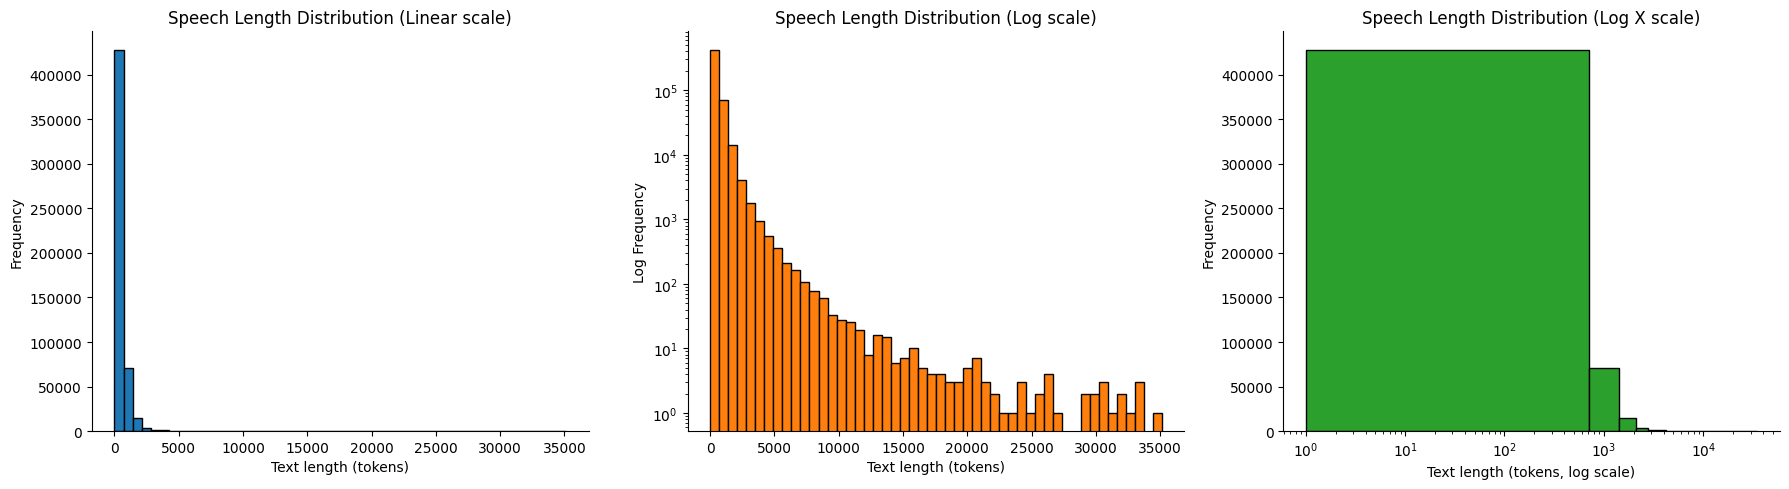

In [68]:
# plot distribution of text_length

plt.figure(figsize=(12,5))

# three subplots side by side
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# linear scale histogram
axes[0].hist(df_debates['text_length'], bins=50, color='C0', edgecolor='black')
axes[0].set_xlabel('Text length (tokens)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Speech Length Distribution (Linear scale)')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# logarithmic scale on y-axis for intuitive understanding
axes[1].hist(df_debates['text_length'], bins=50, color='C1', edgecolor='black', log=True)
axes[1].set_xlabel('Text length (tokens)')
axes[1].set_ylabel('Log Frequency')
axes[1].set_title('Speech Length Distribution (Log scale)')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# logarithmic scale on x-axis 
axes[2].hist(df_debates['text_length'], bins=50, color='C2', edgecolor='black')
axes[2].set_xscale('log')
axes[2].set_xlabel('Text length (tokens, log scale)')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Speech Length Distribution (Log X scale)')
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('images/speech_length_distribution.png')
plt.show()

In [69]:
df_debates.info()

<class 'pandas.core.frame.DataFrame'>
Index: 521129 entries, 1 to 877139
Data columns (total 11 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   doc_id                     521129 non-null  int64         
 1   doc_lp_id                  521129 non-null  int64         
 2   speech_identification_ent  521129 non-null  object        
 3   date                       521129 non-null  datetime64[ns]
 4   period                     521129 non-null  int64         
 5   session                    521129 non-null  int64         
 6   Party                      521129 non-null  object        
 7   Role                       521129 non-null  object        
 8   governing_Party            521129 non-null  object        
 9   text                       521129 non-null  object        
 10  text_length                521129 non-null  int64         
dtypes: datetime64[ns](1), int64(5), object(5)
memory usage: 4

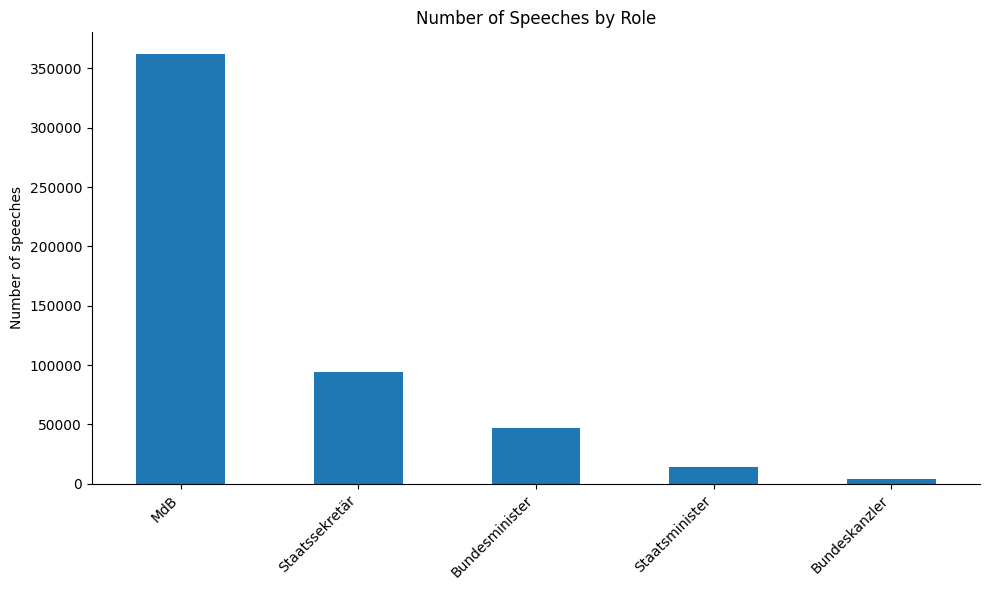

In [70]:
# count total number of speeches per role in cleaned dataset
role_counts = df_debates['Role'].value_counts().reindex(roles).sort_values(ascending=False) 

# Plot
plt.figure(figsize=(10,6))
ax = role_counts.plot(kind='bar', color='C0') 

# save ink
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.ylabel('Number of speeches')
plt.xlabel('')
plt.title('Number of Speeches by Role')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('images/all_speeches_by_role.png')
plt.show()

In [86]:
# stopwords from spacy package: total 543

nlp = spacy.load("de_core_news_sm")
german_stopwords = nlp.Defaults.stop_words

#print(sorted(list(german_stopwords))[:])

In [87]:
# custom stopwords + spacy stopwords for WordCloud
custom_stopwords = german_stopwords.union({'Herr', 'Frau', 'Präsident', 'Präsidentin', 'Bundestag', 'Bundesrat', 'Deutschland', 'Meine', 'Damen', 'Herren', 'Bundesregierung', 'Bundeskanzler', 'Bundeskanzlerin', 'Kanzler', 'Kanzlerin', 'Bundesrepublik', 
                                         'Staatssekretär', 'Staatssekretärin', 'Staatsminister', 'Staatsministerin', 'Bundesminister', 'Bundesministerin', 'Minister', 'Ministerin', 'Meine', 'verehrten',
                                           'Frage', 'Fragen', 'glaube', 'sagen', 'Gesetze', 'Gesetzes', 'Antrag', 'Gesetzentwurf', 'Politik', 'Prozent', 'Kollege', 'Kollegin', 'Kollegen', 'Kolleginnen', 'deutschen', 'deutsche', 'Deutschen', 'deutsch', 'deutschem', 'Regierung',
                                           'eigentlich', 'genau', 'lassen', 'Zusammenhang', 'Länder', 'Ländern', 'Opposition', 'brauchen', 'Thema', 'Auffassung', 'Meinung', 'Gebiet', 'Ausschuß', 'Ausschuss', 'bitte', 'geben', 'stellen', 'steht', 'sehen', 'insbesondere', 
                                           'nämlich', 'Seite', 'Bund', 'Wort', 'Fall', 'Fälle', 'Rahmen', 'einfach', 'geehrte', 'Reden', 'mal', 'Hause', 'wissen', 'geehrter', 'geehrte', 'Herrn', 'gegeben', 'Parlament',
                                           'gilt', 'sage', 'denke', 'liegt', 'gehört', 'gehören', 'weiß', 'sicher', 'letzten', 'letzte', 'letzter', 'letztes', 'Wahlperiode', 'Sitzung',
                                           'deutlich', 'Bereich', 'Lage', 'Art', 'Z B', 'zb', 'z.B.', 'z b', 'z B', 'z B ', ' z B', 'z  B', 'stehen', 'klar', 'finde', 'Punkt', 'Rede', 'einzelnen', 'bereit', 'gesprochen', 'sprechen', 'einzelnen',
                                           'handelt', 'Weise', 'halten', 'Abs', 'übrigen', 'notwendig', 'selbstverständlich', 'getan', 'übrigen', 'j', 'ge', 'ha ben', 'nehmen'
                                        })

In [72]:
# reduced df size for experimental purposes: legislative period 19 (2017-2021)
df_lp19_debates = df_debates[df_debates['period']>18] #26902 rows
df_lp19_debates.shape

(26902, 11)

In [73]:
# Save debates from legislative period 19 df to CSV
df_lp19_debates.to_csv('data/debates_lp19.csv', index=False)

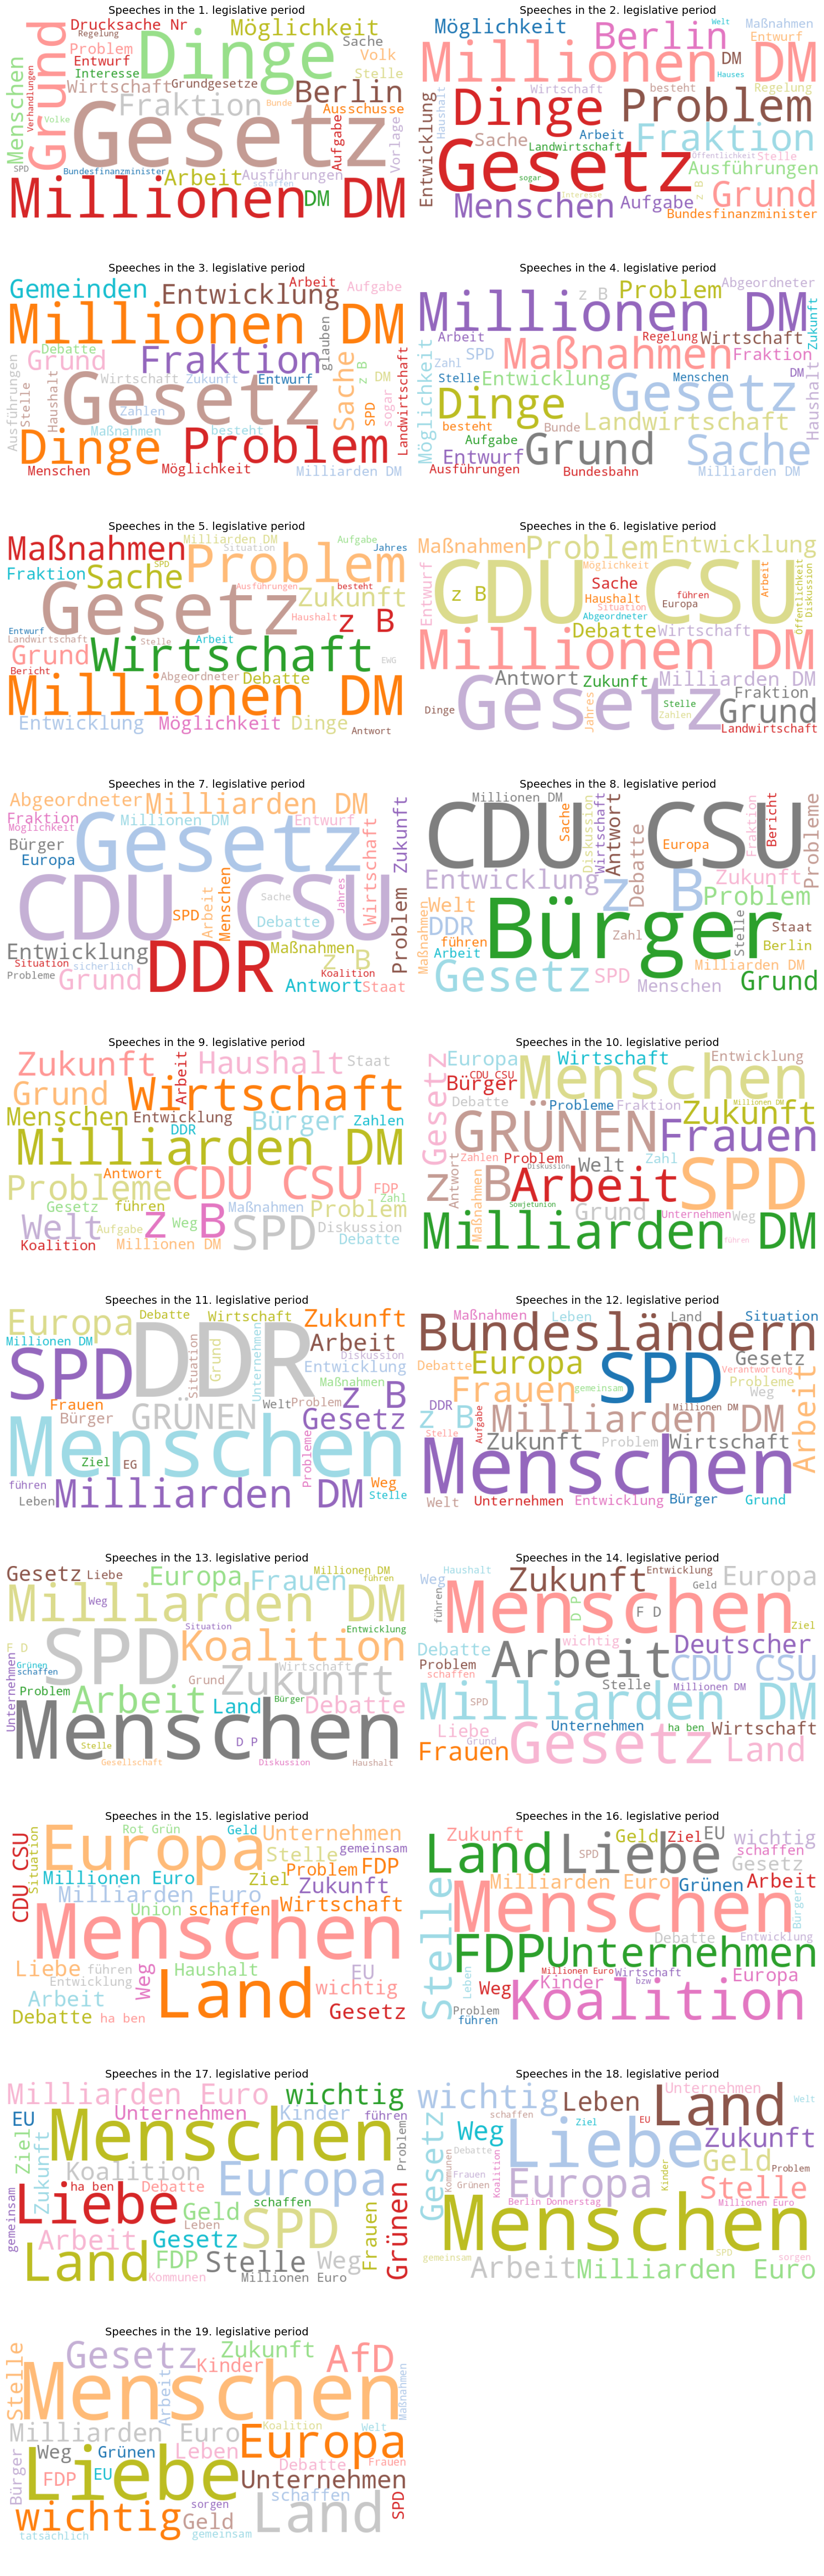

In [90]:
# word cloud per legislative period

# Create one word cloud per legislative period
fig, axes = plt.subplots(nrows=len(period_text)//2 + len(period_text)%2, ncols=2, figsize=(15, 5*len(period_text)//2))

axes = axes.flatten()  # flatten in case of single column

for i, (period, text) in enumerate(sorted(period_text.items())):
    wc = WordCloud(
        stopwords=custom_stopwords,
        width=800, 
        height=400,
        background_color='white',
        max_words=30,
        colormap='tab20'
    ).generate(text)
    wc.to_file(f"images/wordcloud_{period}.png")

    
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].axis('off')
    axes[i].set_title(f'Speeches in the {period}. legislative period', fontsize=14)

# remove any unused axes
for j in range(i+1, len(axes)):
    axes[j].axis('off')

    
plt.tight_layout()
plt.show()